Project Objective

The objective of this project is to analyse historical sales data and build machine learning models capable of forecasting future revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv(r"C:\Users\User\Desktop\Revenue-forecasting.ml\data\train.csv")

In [5]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
df.shape

(913000, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [10]:
df["year"] = df["date"].dt.year

In [12]:
df.head()

,date,store,item,sales,year
0,2013-01-01,1,1,13,2013
1,2013-01-02,1,1,11,2013
2,2013-01-03,1,1,14,2013
3,2013-01-04,1,1,13,2013
4,2013-01-05,1,1,10,2013


In [13]:
df["month"] = df["date"].dt.month

In [14]:
df["day"] = df["date"].dt.day

In [15]:
df["day_of_week"] = df["date"].dt.dayofweek

In [16]:
df["quarter"] = df["date"].dt.quarter

In [17]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1
2,2013-01-03,1,1,14,2013,1,3,3,1
3,2013-01-04,1,1,13,2013,1,4,4,1
4,2013-01-05,1,1,10,2013,1,5,5,1


In [18]:
df["sales_lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)

In [19]:
df.head(10)

,date,store,item,sales,year,month,day,day_of_week,quarter,sales_lag_1
0,2013-01-01,1,1,13,2013,1,1,1,1,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,13.0
2,2013-01-03,1,1,14,2013,1,3,3,1,11.0
3,2013-01-04,1,1,13,2013,1,4,4,1,14.0
4,2013-01-05,1,1,10,2013,1,5,5,1,13.0
5,2013-01-06,1,1,12,2013,1,6,6,1,10.0
6,2013-01-07,1,1,10,2013,1,7,0,1,12.0
7,2013-01-08,1,1,9,2013,1,8,1,1,10.0
8,2013-01-09,1,1,12,2013,1,9,2,1,9.0
9,2013-01-10,1,1,9,2013,1,10,3,1,12.0


In [20]:
df["rolling_mean_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [22]:
df.head(10)

,date,store,item,sales,year,month,day,day_of_week,quarter,sales_lag_1,rolling_mean_7
0,2013-01-01,1,1,13,2013,1,1,1,1,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,13.0,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,11.0,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,14.0,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,13.0,NaN
5,2013-01-06,1,1,12,2013,1,6,6,1,10.0,NaN
6,2013-01-07,1,1,10,2013,1,7,0,1,12.0,NaN
7,2013-01-08,1,1,9,2013,1,8,1,1,10.0,11.857143
8,2013-01-09,1,1,12,2013,1,9,2,1,9.0,11.285714
9,2013-01-10,1,1,9,2013,1,10,3,1,12.0,11.428571


In [23]:
df = df.dropna()

In [24]:
df.shape

(909500, 11)

In [25]:
daily_sales = df.groupby("date")["sales"].sum()

In [26]:
daily_sales.head()

date
2013-01-08    13560
2013-01-09    13878
2013-01-10    14642
2013-01-11    15633
2013-01-12    16679
Name: sales, dtype: int64

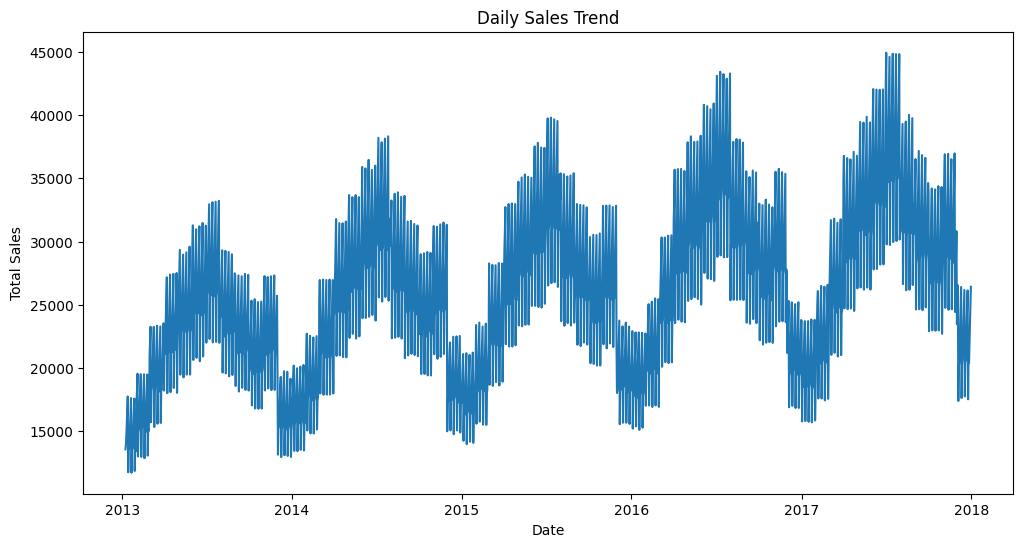

In [27]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.show()

Daily Sales Trend

The daily sales trend shows a clear upward trend throughout the observation period, indicating that overall demand increases over time.

The data also demonstrates strong seasonal patterns, with sales rising and falling in a consistent cycle each year. In addition, short-term fluctuations suggest the presence of weekly purchasing patterns.

These observations indicate that time-based features such as year, month, and day of the week are likely to be valuable predictors in the machine learning model.

In [28]:
monthly_sales = df.groupby("month")["sales"].mean()

In [29]:
monthly_sales

month
1     35.815041
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64

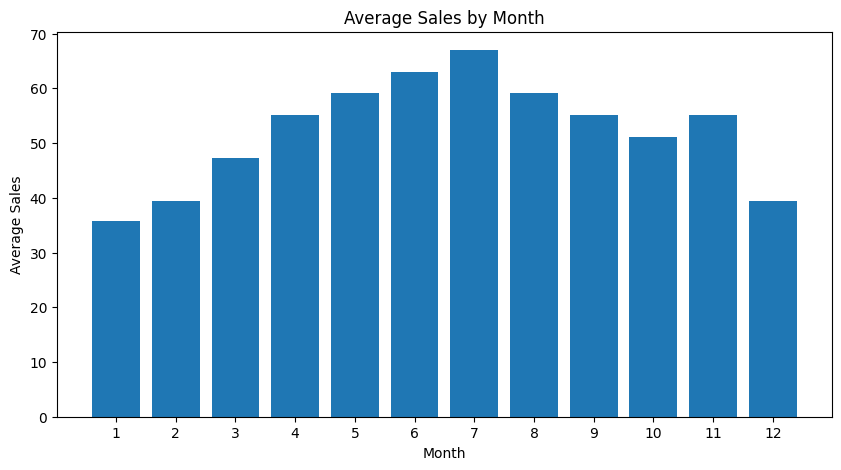

In [30]:
plt.figure(figsize=(10,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Average Sales by Month")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.xticks(range(1,13))

plt.show()

In [31]:
df["rolling_std_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).std())
)

In [32]:
df.head(10)

,date,store,item,sales,year,month,day,day_of_week,quarter,sales_lag_1,rolling_mean_7,rolling_std_7
7,2013-01-08,1,1,9,2013,1,8,1,1,10.0,11.857143,NaN
8,2013-01-09,1,1,12,2013,1,9,2,1,9.0,11.285714,NaN
9,2013-01-10,1,1,9,2013,1,10,3,1,12.0,11.428571,NaN
10,2013-01-11,1,1,9,2013,1,11,4,1,9.0,10.714286,NaN
11,2013-01-12,1,1,7,2013,1,12,5,1,9.0,10.142857,NaN
12,2013-01-13,1,1,10,2013,1,13,6,1,7.0,9.714286,NaN
13,2013-01-14,1,1,12,2013,1,14,0,1,10.0,9.428571,NaN
14,2013-01-15,1,1,5,2013,1,15,1,1,12.0,9.714286,1.799471
15,2013-01-16,1,1,7,2013,1,16,2,1,5.0,9.142857,2.544836
16,2013-01-17,1,1,16,2013,1,17,3,1,7.0,8.428571,2.299068


In [33]:
df = df.dropna()

In [34]:
df.shape

(906000, 12)

In [35]:
y = df["sales"]

In [36]:
X = df[[
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "sales_lag_1",
    "rolling_mean_7",
    "rolling_std_7"
]]

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
model = LinearRegression()

In [42]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0. ,-0. , 0.02,...,-0. , 1. ,-0.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['store','item','year',...,'sales_lag_1','rolling_mean_7','rolling_std_7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-56.86
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [43]:
y_pred = model.predict(X_test)

In [44]:
y_pred[:10]

array([ 66.81668342,  49.8864126 ,  62.49354262,  14.0014674 ,
        79.31867565,  37.91499158, 119.33088675,  46.40678695,
        38.223226  , 103.52601756])

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

In [47]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 6.781366914113494
RMSE: 8.786952887730198
R²: 0.9066759430899902


In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [50]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [51]:
rf_pred = rf_model.predict(X_test)

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MAE: 6.154543818984546
RMSE: 7.9873706209229045
R²: 0.9228875170642035


In [53]:
comparison_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

comparison_results

,Model,MAE,RMSE,R²
0,Linear Regression,6.781367,8.786953,0.906676
1,Random Forest,6.154544,7.987371,0.922888


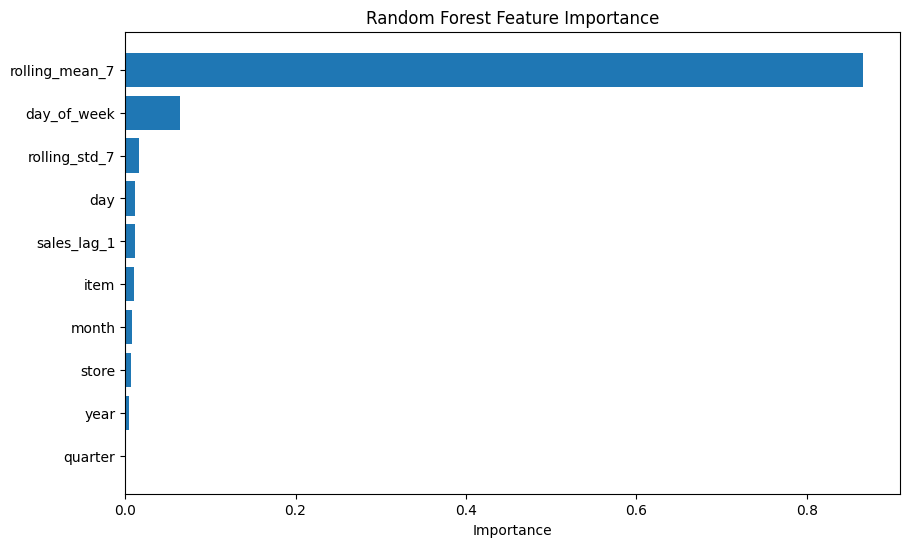

In [55]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [56]:
from xgboost import XGBRegressor

In [57]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42

)

In [58]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [59]:
xgb_pred = xgb_model.predict(X_test)

In [60]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

MAE: 5.96650505065918
RMSE: 7.742399611199486
R²: 0.9275450110435486


In [61]:
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R²": [
        r2,
        rf_r2,
        xgb_r2
    ]
})

comparison_results

,Model,MAE,RMSE,R²
0,Linear Regression,6.781367,8.786953,0.906676
1,Random Forest,6.154544,7.987371,0.922888
2,XGBoost,5.966505,7.742400,0.927545


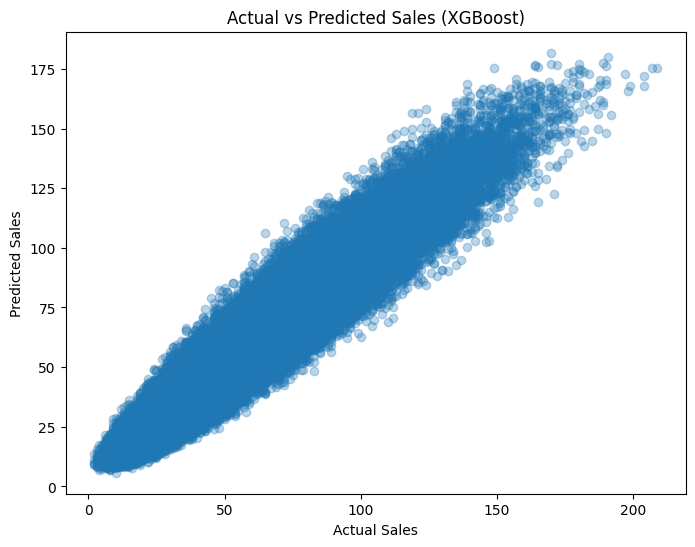

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, xgb_pred, alpha=0.3)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales (XGBoost)")

plt.show()

In [63]:
residuals = y_test - xgb_pred

In [64]:
residuals.head()

514590     8.876648
289815    -5.470776
229064   -10.872528
604393    -2.701555
107467     7.114937
Name: sales, dtype: float64

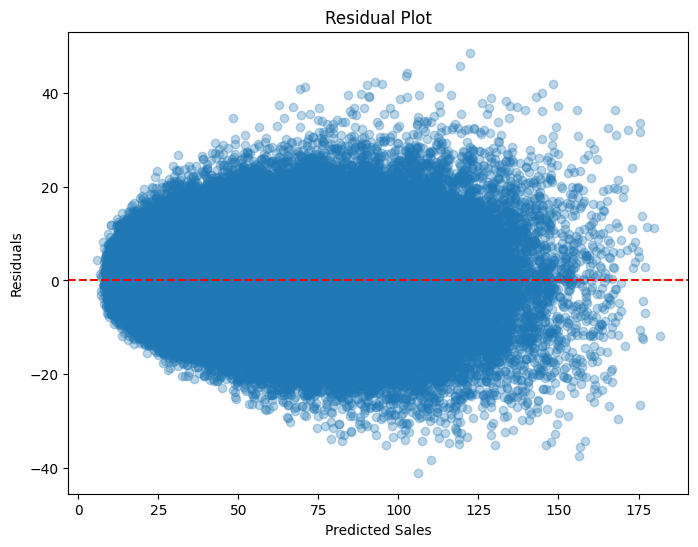

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(xgb_pred, residuals, alpha=0.3)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [66]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_pred
})

comparison.head(20)

,Actual Sales,Predicted Sales
0,76,67.123352
1,42,47.470776
2,51,61.872528
3,17,19.701555
4,90,82.885063
5,35,45.253944
6,126,118.455620
7,45,45.069736
8,35,41.952652
9,116,106.563881


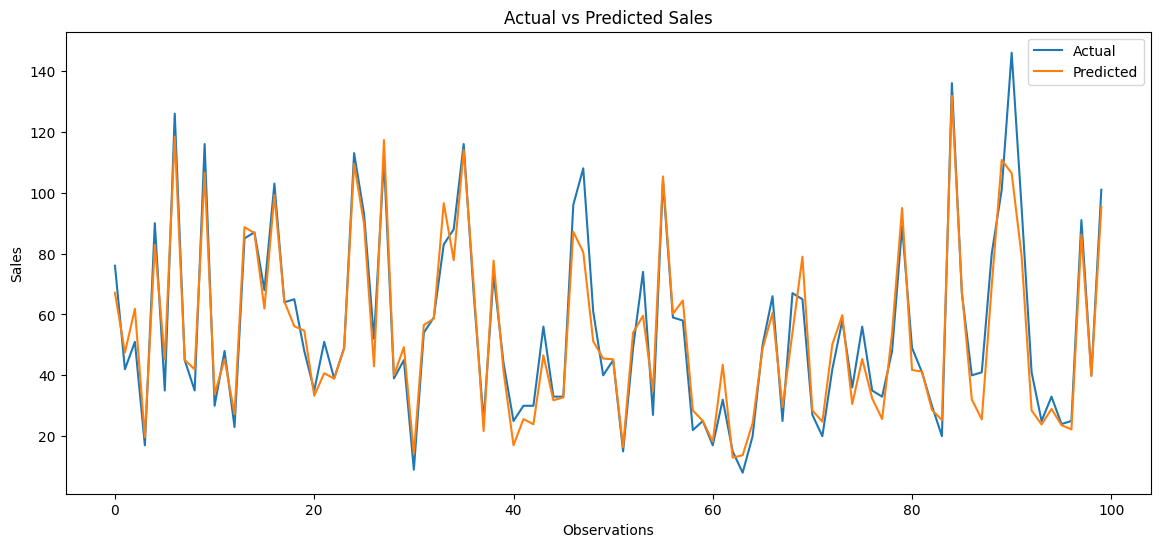

In [67]:
plt.figure(figsize=(14,6))

plt.plot(comparison["Actual Sales"].values[:100], label="Actual")

plt.plot(comparison["Predicted Sales"].values[:100], label="Predicted")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Observations")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [68]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_pred
})

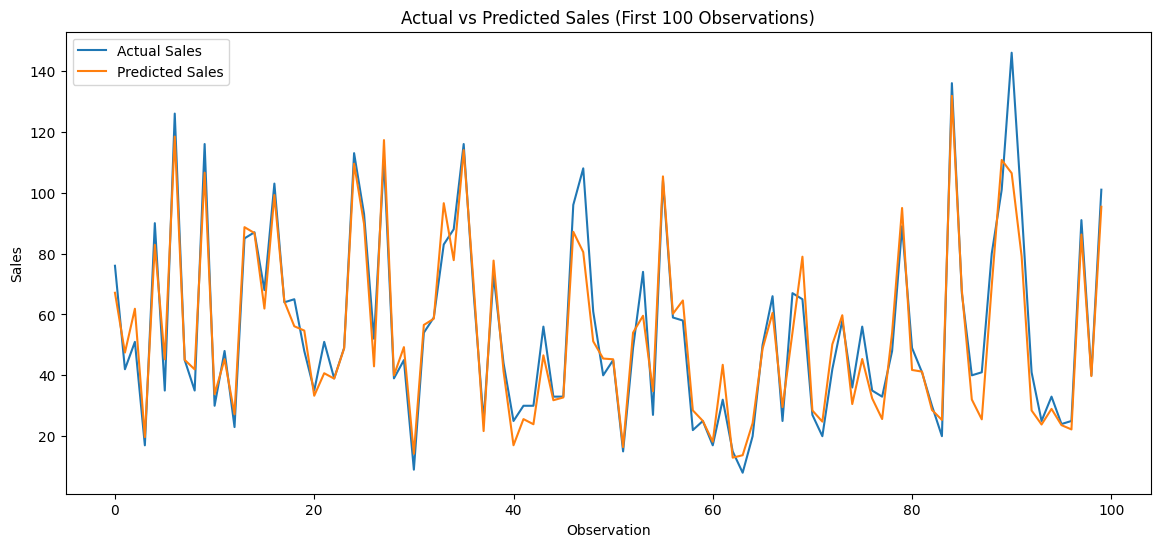

In [69]:
plt.figure(figsize=(14,6))

plt.plot(comparison["Actual Sales"].values[:100], label="Actual Sales")
plt.plot(comparison["Predicted Sales"].values[:100], label="Predicted Sales")

plt.title("Actual vs Predicted Sales (First 100 Observations)")
plt.xlabel("Observation")
plt.ylabel("Sales")
plt.legend()

plt.show()

# Business Conclusions

The analysis demonstrated that historical sales patterns are highly predictive of future sales.

Three machine learning models were evaluated: Linear Regression, Random Forest and XGBoost.

XGBoost achieved the best performance with:
- MAE = 5.97
- RMSE = 7.74
- R² = 0.928

Feature importance analysis showed that the 7-day rolling average was the most influential predictor, followed by the day of the week.

These findings suggest that incorporating historical sales trends and temporal features significantly improves forecasting accuracy.

# Limitations

Although the model achieved strong predictive performance, there are several limitations.

- External factors such as promotions, holidays and weather were not included.
- The dataset represents historical behaviour and may not capture future market changes.
- Additional business features could further improve forecasting performance.

# Future Improvements

Possible improvements include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Adding holiday and promotional data.
- Including weather information.
- Testing deep learning models such as LSTM for time-series forecasting.
- Deploying the model as a web application using Flask or Streamlit.

In [70]:
import joblib

joblib.dump(xgb_model, "xgboost_revenue_forecasting_model.pkl")

['xgboost_revenue_forecasting_model.pkl']